# Installation

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import pandas as pd
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_auc_score,precision_recall_curve, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

In [9]:
def show_heatmap(model, context_size):
  fig, ax = plt.subplots(figsize=(9, 4))

  importances = model.feature_importances_
  importance_matrix = importances.reshape(2*context_size + 2, 4)
  pos_importance = importance_matrix.sum(axis=1)
  most_important_idx = np.argpartition(pos_importance, -10)[-10:]

  positions = np.arange(2*context_size + 2)[most_important_idx]
  positions_sorted = np.sort(np.concatenate([positions, [context_size,context_size+1]]))

  im = ax.imshow(importance_matrix[positions_sorted, :].T, aspect='auto')

  x_indices = range(len(positions_sorted))

  ax.set_xticks(x_indices)
  ax.set_xticklabels(positions_sorted - context_size)

  nucleotides = ['A', 'C', 'G', 'T']
  ax.set_yticks(np.arange(len(nucleotides)))
  ax.set_yticklabels(nucleotides, fontsize=12)
  ax.set_ylabel('Nucleotide', fontsize=12)
  cbar = fig.colorbar(im, ax=ax)
  cbar.set_label('Feature Importance', rotation=270, labelpad=15, fontsize=14)
  ax.set_xlabel('Nucleotide Context Position', fontsize=14)
  ax.set_ylabel('Nucleotide', fontsize=14)
  plt.xticks(fontsize=12)
  plt.yticks(fontsize=12)

  plt.title('Top Most Significant Context Position Heatmap', fontsize=16, pad=15)
  plt.tight_layout()

  plt.show()

In [10]:
def show_shap_values(model, X_test, context_size):
  nucleotides = ['A', 'C', 'G', 'T']
  feature_names = []
  for pos in range(context_size*2 + 2):
      for nuc in nucleotides:
          feature_names.append(f"{nuc} (at position {pos-context_size})")

  X_test_df = pd.DataFrame(X_test, columns=feature_names)
  explainer = shap.TreeExplainer(model)
  shap_values = explainer.shap_values(X_test_df)
  plt.figure(figsize=(12, 8))
  shap.summary_plot(shap_values, X_test_df, max_display=15, show=False)

  plt.gcf().suptitle('Influence of Nucleotide Context \n on Mutation Probability',
                    fontsize=16, y=0.98)
  ax_main = plt.gca()
  ax_main.set_xlabel("SHAP value", fontsize=12)

  for ax in plt.gcf().axes:
      if ax.get_ylabel() == "Feature value":
          ax.set_ylabel("Feature value", fontsize=14)

      labels = [t.get_text().strip() for t in ax.get_yticklabels()]

      if 'High' in labels or 'Low' in labels:
          ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
          ax.set_yticklabels(['Nucleotide\n Absence', 'Nucleotide\n Presence'], fontsize=12)

  plt.subplots_adjust(top=0.92, bottom=0.1, left=0.2, right=0.9)
  plt.show()

In [11]:
data = np.load('data/processed/models_input.npz')

X_50 = data['X_50']
X_30 = data['X_30']
y = data['y']
Z = data['Z']
pos = data['pos']

weights = 1 + np.log1p(Z)

# Classification of 50-bp Nucleotide Context

## Model Initialization and Training

In [12]:
X_train_50, X_test_50, y_train_50, y_test_50, w_train_50, w_test_50 = train_test_split(X_50, y, weights, test_size=0.2, shuffle=True, random_state=42)

In [13]:
best_params_50 ={'colsample_bytree': 0.6,
               'gamma': 0,
               'learning_rate': 0.05,
               'max_depth': 3,
               'min_child_weight': 1,
               'n_estimators': 200,
               'scale_pos_weight': Counter(y_train_50)[0]/Counter(y_train_50)[1],
               'subsample': 0.6}

In [14]:
# Parameters tuned using cross-validation
model_50=XGBClassifier(n_estimators=best_params_50['n_estimators'],
                    learning_rate=best_params_50['learning_rate'],
                    max_depth=best_params_50['max_depth'],
                    gamma=best_params_50['gamma'],
                    colsample_bytree=best_params_50['colsample_bytree'],
                    subsample=best_params_50['subsample'],
                    min_child_weight=best_params_50['min_child_weight'],
                    scale_pos_weight=best_params_50['scale_pos_weight'])

In [15]:
model_50.fit(X_train_50, y_train_50)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluation Metrics

In [16]:
y_pred_50 = model_50.predict(X_test_50)
y_probs_50 = model_50.predict_proba(X_test_50)[:, 1]

In [17]:
print(classification_report(y_test_50, y_pred_50))
print(f"ROC-AUC: {roc_auc_score(y_test_50, y_probs_50):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.67      0.78      4230
           1       0.16      0.60      0.25       433

    accuracy                           0.67      4663
   macro avg       0.55      0.64      0.52      4663
weighted avg       0.87      0.67      0.73      4663

ROC-AUC: 0.6869


In [18]:
fpr_50, tpr_50, _ = roc_curve(y_test_50,  y_probs_50)

In [19]:
precision_50, recall_50, thresholds_50 = precision_recall_curve(y_test_50, y_probs_50)

## Model Interpretation

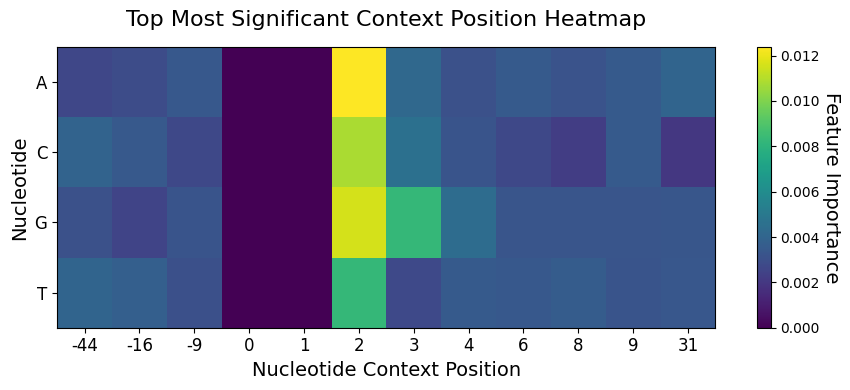

In [20]:
show_heatmap(model_50, 50)

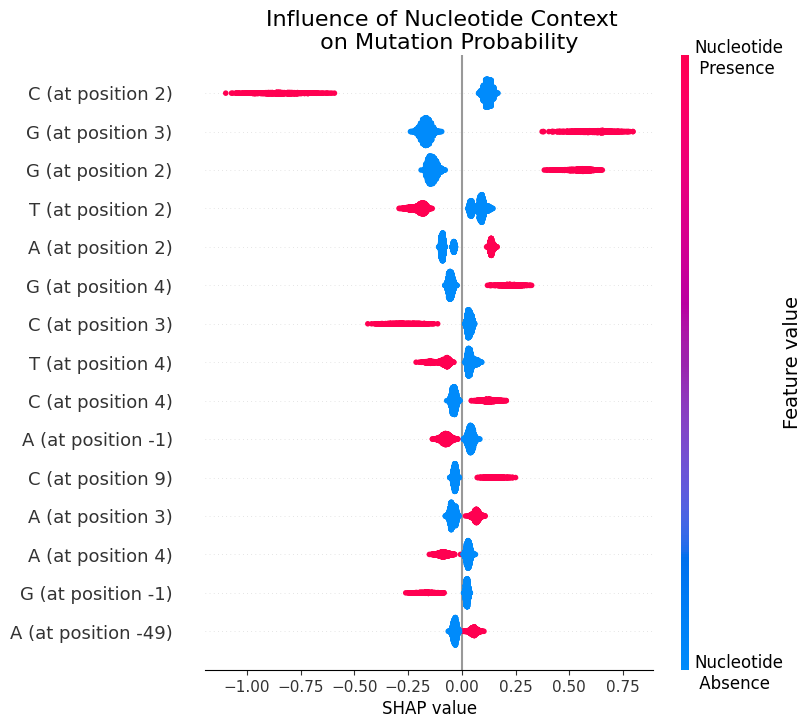

In [21]:
show_shap_values(model_50, X_test_50, 50)

# Classification of 30-bp Nucleotide Context

## Model Initialization and Training

In [22]:
X_train_30, X_test_30, y_train_30, y_test_30, w_train_30, w_test_30  = train_test_split(X_30, y, weights, test_size=0.2, shuffle=True, random_state=42)

In [23]:
best_params_30 = {'colsample_bytree': 0.8,
                'gamma': 0,
                'learning_rate': 0.1,
                'max_depth': 3,
                'min_child_weight': 1,
                'n_estimators': 100,
                'scale_pos_weight': Counter(y_train_30)[0]/Counter(y_train_30)[1],
                'subsample': 0.8}

In [24]:
# Parameters tuned using cross-validation
model_30=XGBClassifier(n_estimators=best_params_30['n_estimators'],
                    learning_rate=best_params_30['learning_rate'],
                    max_depth=best_params_30['max_depth'],
                    gamma=best_params_30['gamma'],
                    colsample_bytree=best_params_30['colsample_bytree'],
                    subsample=best_params_30['subsample'],
                    min_child_weight=best_params_30['min_child_weight'],
                    scale_pos_weight=best_params_30['scale_pos_weight'])

In [25]:
model_30.fit(X_train_30, y_train_30)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluation Metrics

In [26]:
y_pred_30 = model_30.predict(X_test_30)
y_probs_30 = model_30.predict_proba(X_test_30)[:, 1]

In [27]:
print(classification_report(y_test_30, y_pred_30))
print(f"ROC-AUC: {roc_auc_score(y_test_30, y_probs_30):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.66      0.78      4230
           1       0.16      0.61      0.25       433

    accuracy                           0.66      4663
   macro avg       0.55      0.63      0.51      4663
weighted avg       0.87      0.66      0.73      4663

ROC-AUC: 0.6844


In [28]:
fpr_30, tpr_30, _ = roc_curve(y_test_30,  y_probs_30)

In [29]:
precision_30, recall_30, thresholds_30 = precision_recall_curve(y_test_30, y_probs_30)

## Model Interpretation

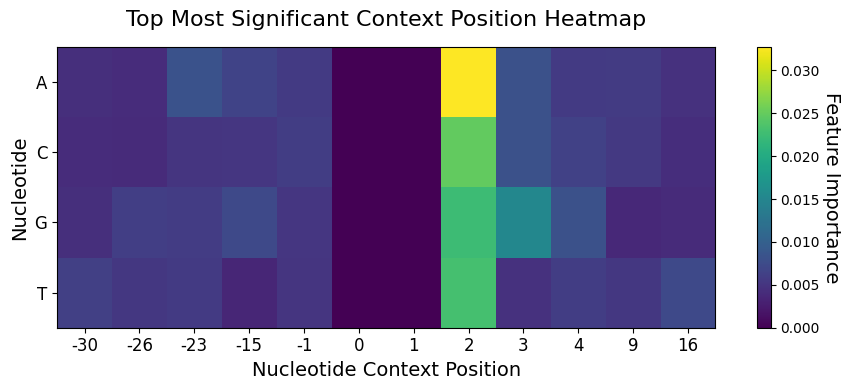

In [30]:
show_heatmap(model_30, 30)

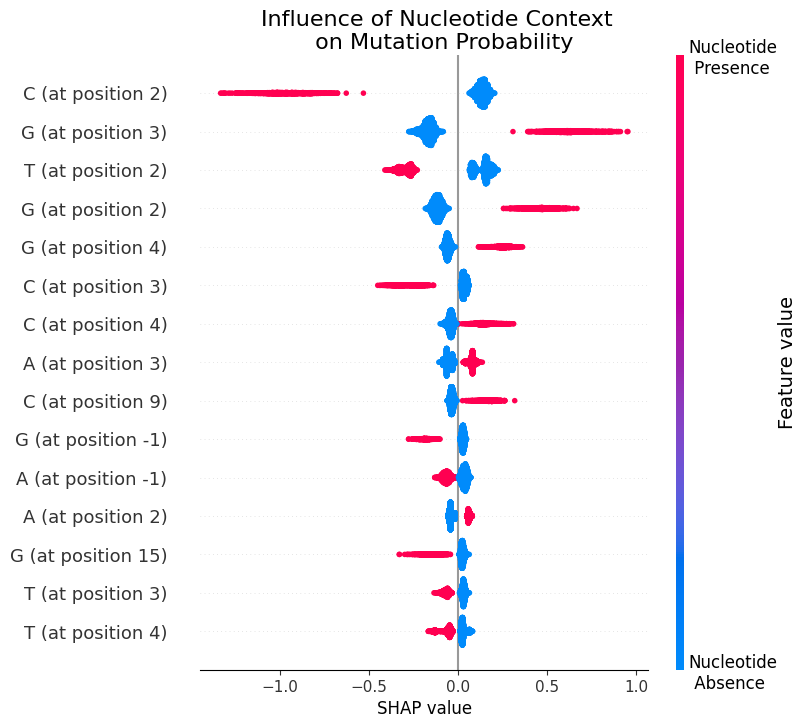

In [31]:
show_shap_values(model_30, X_test_30, 30)

# Weighted Classification of 50-bp Nucleotide Context

## Model Initialization and Training

In [32]:
best_params_50_w = {'colsample_bytree': 0.6,
                    'gamma': 0,
                    'learning_rate': 0.05,
                    'max_depth': 3,
                    'min_child_weight': 5,
                    'n_estimators': 1000,
                    'scale_pos_weight': Counter(y_train_50)[0]/Counter(y_train_50)[1],
                    'subsample': 0.8}

In [33]:
model_50_w=XGBClassifier(n_estimators=best_params_50_w['n_estimators'],
                    learning_rate=best_params_50_w['learning_rate'],
                    max_depth=best_params_50_w['max_depth'],
                    gamma=best_params_50_w['gamma'],
                    colsample_bytree=best_params_50_w['colsample_bytree'],
                    subsample=best_params_50_w['subsample'],
                    min_child_weight=best_params_50_w['min_child_weight'],
                    scale_pos_weight=best_params_50_w['scale_pos_weight'])

model_50_w.fit(X_train_50, y_train_50, sample_weight=w_train_50)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluation Metrics

In [34]:
y_pred_50 = model_50_w.predict(X_test_50)
y_probs_50 = model_50_w.predict_proba(X_test_50)[:, 1]

In [35]:
print(classification_report(y_test_50, y_pred_50))
print(f"ROC-AUC: {roc_auc_score(y_test_50, y_probs_50):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.63      0.75      4230
           1       0.15      0.64      0.24       433

    accuracy                           0.63      4663
   macro avg       0.55      0.63      0.50      4663
weighted avg       0.87      0.63      0.71      4663

ROC-AUC: 0.6771


In [36]:
fpr_50_w, tpr_50_w, _ = roc_curve(y_test_50,  y_probs_50)

In [37]:
precision_50_w, recall_50_w, thresholds_50_w = precision_recall_curve(y_test_50, y_probs_50)

# Weighted Classification of 30-bp Nucleotide Context

## Model Initialization and Training

In [38]:
best_params_30_w = {'colsample_bytree': 0.8,
                    'gamma': 0,
                    'learning_rate': 0.05,
                    'max_depth': 3,
                    'min_child_weight': 1,
                    'n_estimators': 1000,
                    'scale_pos_weight': Counter(y_train_50)[0]/Counter(y_train_50)[1],
                    'subsample': 0.8}

In [39]:
model_30_w = XGBClassifier(n_estimators=best_params_30_w['n_estimators'],
                    learning_rate=best_params_30_w['learning_rate'],
                    max_depth=best_params_30_w['max_depth'],
                    gamma=best_params_30_w['gamma'],
                    colsample_bytree=best_params_30_w['colsample_bytree'],
                    subsample=best_params_30_w['subsample'],
                    min_child_weight=best_params_30_w['min_child_weight'],
                    scale_pos_weight=best_params_30_w['scale_pos_weight'])

model_30_w.fit(X_train_30, y_train_30, sample_weight=w_train_30)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluation Metrics

In [40]:
y_pred_30 = model_30_w.predict(X_test_30)
y_probs_30 = model_30_w.predict_proba(X_test_30)[:, 1]

In [41]:
print(classification_report(y_test_30, y_pred_30))
print(f"ROC-AUC: {roc_auc_score(y_test_30, y_probs_30):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.60      0.74      4230
           1       0.14      0.64      0.23       433

    accuracy                           0.61      4663
   macro avg       0.54      0.62      0.48      4663
weighted avg       0.87      0.61      0.69      4663

ROC-AUC: 0.6669


In [42]:
fpr_30_w, tpr_30_w, _ = roc_curve(y_test_30,  y_probs_30)

In [43]:
precision_30_w, recall_30_w, thresholds_30_w = precision_recall_curve(y_test_30, y_probs_30)

# Adding Features

In [44]:
df = pd.DataFrame({'pos': pos, 'seq_50':list(X_50), 'seq_30':list(X_30), 'label': y})
score_df = pd.read_pickle('data/processed/grantham_score.pkl.gz')
score_df.score = score_df.score.fillna(215)

df = df.merge(score_df[['pos', 'score']], on='pos', how='left')
df.score = df.score.fillna(0)

In [45]:
add_features = pd.read_pickle('data/processed/dataframe_features.pkl.gz')

In [46]:
df_featured = df[df.pos.isin(add_features.pos_in_align)]
df_featured = df_featured.merge(
    add_features[['pos_in_align', 'Free_Energy_kcal_mol', 'Stem_Length', 'Loop_Length']],
    left_on='pos',
    right_on='pos_in_align',
    how='left'
)

df_featured = df_featured.drop(columns=['pos_in_align'])

In [47]:
features = df_featured[['score', 'Free_Energy_kcal_mol', 'Stem_Length', 'Loop_Length']].values

X_50_featured = np.hstack((np.vstack(df_featured.seq_50), features))
X_30_featured = np.hstack((np.vstack(df_featured.seq_30), features))

y_featured = df_featured.label.to_numpy()

# Classification of 50-bp Nucleotide Context with Additional Features

## Model Initialization and Training

In [48]:
X_train_50_featured, X_test_50_featured, y_train_50_featured, y_test_50_featured = train_test_split(X_50_featured,
                                                                                                    y_featured,
                                                                                                    test_size=0.2,
                                                                                                    shuffle=True,
                                                                                                    random_state=42)

In [49]:
best_params_50_featured ={'colsample_bytree': 0.6,
               'gamma': 0,
               'learning_rate': 0.01,
               'max_depth': 3,
               'min_child_weight': 3,
               'n_estimators': 1000,
               'scale_pos_weight': Counter(y_train_50_featured)[0]/Counter(y_train_50_featured)[1],
               'subsample': 0.6}

In [50]:
model_50_featured = XGBClassifier(n_estimators=best_params_50_featured['n_estimators'],
                                  learning_rate=best_params_50_featured['learning_rate'],
                                  max_depth=best_params_50_featured['max_depth'],
                                  gamma=best_params_50_featured['gamma'],
                                  colsample_bytree=best_params_50_featured['colsample_bytree'],
                                  subsample=best_params_50_featured['subsample'],
                                  min_child_weight=best_params_50_featured['min_child_weight'],
                                  scale_pos_weight=best_params_50_featured['scale_pos_weight'])

In [51]:
model_50_featured.fit(X_train_50_featured, y_train_50_featured)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluation Metrics

In [52]:
y_pred_50_featured = model_50_featured.predict(X_test_50_featured)
y_probs_50_featured = model_50_featured.predict_proba(X_test_50_featured)[:, 1]

In [53]:
print(classification_report(y_test_50_featured, y_pred_50_featured))
print(f"ROC-AUC: {roc_auc_score(y_test_50_featured, y_probs_50_featured):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.71      0.81      4222
           1       0.18      0.61      0.28       439

    accuracy                           0.70      4661
   macro avg       0.56      0.66      0.54      4661
weighted avg       0.87      0.70      0.76      4661

ROC-AUC: 0.7236


In [54]:
fpr_50_featured, tpr_50_featured, _ = roc_curve(y_test_50_featured,  y_probs_50_featured)

In [55]:
precision_50_featured, recall_50_featured, thresholds_50_featured = precision_recall_curve(y_test_50_featured, y_probs_50_featured)

## Features Interpretation

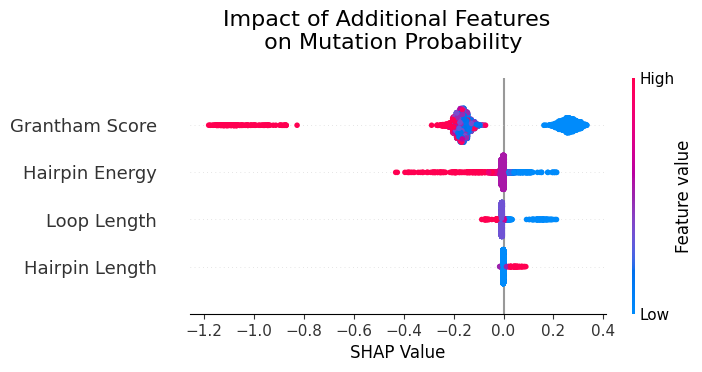

In [56]:
explainer = shap.TreeExplainer(model_50_featured)
shap_values = explainer.shap_values(X_test_50_featured)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

feature_names_last4 = ['Grantham Score', 'Hairpin Energy', 'Hairpin Length', 'Loop Length']
shap_values_last4 = shap_values_to_plot[:, -4:]
data_last4 = X_test_50_featured[:, -4:]


X_test_last4_df = pd.DataFrame(data_last4, columns=feature_names_last4)


plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_last4,
    X_test_last4_df,
    max_display=4,
    show=False,
    plot_type="dot"
)


plt.gcf().suptitle('Impact of Additional Features \n on Mutation Probability',
                    fontsize=16, y=1.1)
ax_main = plt.gca()
ax_main.set_xlabel("SHAP Value", fontsize=12)
ax_main.tick_params(axis='y', labelsize=13)
plt.subplots_adjust(top=0.88, bottom=0.12, left=0.25, right=0.9)

plt.show()

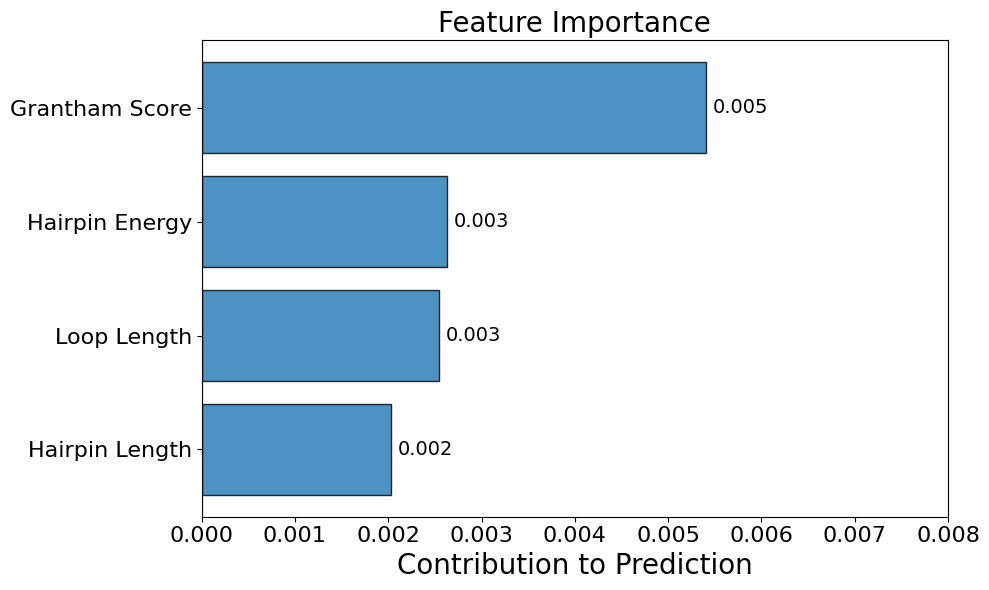

In [57]:
features = ['Grantham Score', 'Hairpin Energy', 'Hairpin Length', 'Loop Length']

df_weights = pd.DataFrame({'feature': features, 'weight': model_50_featured.feature_importances_[-4:]})
df_weights = df_weights.sort_values(by='weight')

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_weights['feature'], df_weights['weight'], edgecolor='black', alpha=0.8)
ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=14)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(0, 0.008)
ax.set_title('Feature Importance', fontsize=20)
ax.set_xlabel('Contribution to Prediction', fontsize=20)
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Classification of 30-bp Nucleotide Context with Additional Features

## Model Initialization and Training

In [58]:
X_train_30_featured, X_test_30_featured, y_train_30_featured, y_test_30_featured = train_test_split(X_30_featured,
                                                                                                    y_featured,
                                                                                                    test_size=0.2,
                                                                                                    shuffle=True,
                                                                                                    random_state=42)

In [59]:
best_params_30_featured ={'colsample_bytree': 0.8,
               'gamma': 0.2,
               'learning_rate': 0.05,
               'max_depth': 3,
               'min_child_weight': 1,
               'n_estimators': 500,
               'scale_pos_weight': Counter(y_train_30_featured)[0]/Counter(y_train_30_featured)[1],
               'subsample': 0.8}

In [60]:
model_30_featured = XGBClassifier(n_estimators=best_params_30_featured['n_estimators'],
                                  learning_rate=best_params_30_featured['learning_rate'],
                                  max_depth=best_params_30_featured['max_depth'],
                                  gamma=best_params_30_featured['gamma'],
                                  colsample_bytree=best_params_30_featured['colsample_bytree'],
                                  subsample=best_params_30_featured['subsample'],
                                  min_child_weight=best_params_30_featured['min_child_weight'],
                                  scale_pos_weight=best_params_30_featured['scale_pos_weight'])

In [61]:
model_30_featured.fit(X_train_30_featured, y_train_30_featured)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluation Metrics

In [62]:
y_pred_30_featured = model_30_featured.predict(X_test_30_featured)
y_probs_30_featured = model_30_featured.predict_proba(X_test_30_featured)[:, 1]

In [63]:
print(classification_report(y_test_30_featured, y_pred_30_featured))
print(f"ROC-AUC: {roc_auc_score(y_test_30_featured, y_probs_30_featured):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.74      0.83      4222
           1       0.19      0.58      0.28       439

    accuracy                           0.72      4661
   macro avg       0.56      0.66      0.55      4661
weighted avg       0.87      0.72      0.78      4661

ROC-AUC: 0.7165


In [64]:
fpr_30_featured, tpr_30_featured, _ = roc_curve(y_test_30_featured,  y_probs_30_featured)

In [65]:
precision_30_featured, recall_30_featured, thresholds_30_featured = precision_recall_curve(y_test_30_featured, y_probs_30_featured)

## Features Interpretation

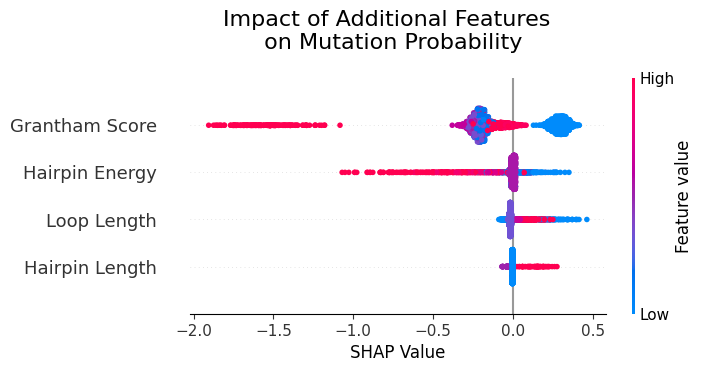

In [66]:
explainer = shap.TreeExplainer(model_30_featured)
shap_values = explainer.shap_values(X_test_30_featured)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

feature_names_last4 = ['Grantham Score', 'Hairpin Energy', 'Hairpin Length', 'Loop Length']
shap_values_last4 = shap_values_to_plot[:, -4:]
data_last4 = X_test_30_featured[:, -4:]


X_test_last4_df = pd.DataFrame(data_last4, columns=feature_names_last4)


plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_last4,
    X_test_last4_df,
    max_display=4,
    show=False,
    plot_type="dot"
)


plt.gcf().suptitle('Impact of Additional Features \n on Mutation Probability',
                    fontsize=16, y=1.1)
ax_main = plt.gca()
ax_main.set_xlabel("SHAP Value", fontsize=12)
ax_main.tick_params(axis='y', labelsize=13)
plt.subplots_adjust(top=0.88, bottom=0.12, left=0.25, right=0.9)

plt.show()

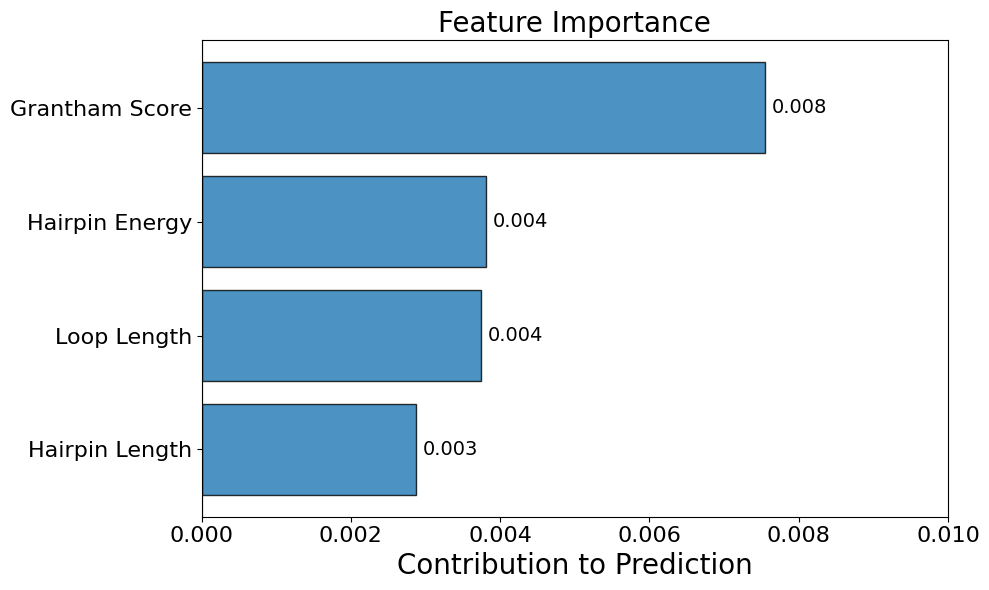

In [67]:
features = ['Grantham Score', 'Hairpin Energy', 'Hairpin Length', 'Loop Length']

df_weights = pd.DataFrame({'feature': features, 'weight': model_30_featured.feature_importances_[-4:]})
df_weights = df_weights.sort_values(by='weight')

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_weights['feature'], df_weights['weight'], edgecolor='black', alpha=0.8)
ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=14)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(0, 0.01)
ax.set_title('Feature Importance', fontsize=20)
ax.set_xlabel('Contribution to Prediction', fontsize=20)
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Evaluation of Predictive Performance

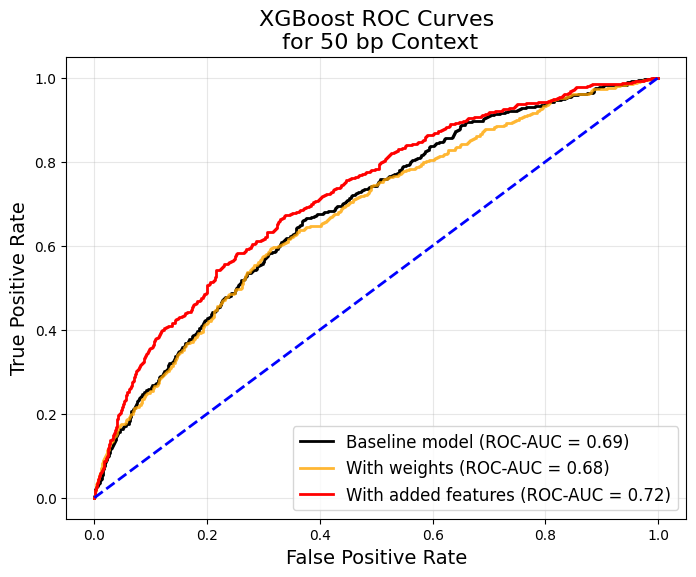

In [68]:
plt.figure(figsize=(8, 6))
models = [
    (fpr_50, tpr_50, 'Baseline model', 'black', '-', 1.0),
    (fpr_50_w, tpr_50_w, 'With weights', 'orange', '-', 0.8),
    (fpr_50_featured, tpr_50_featured, 'With added features', 'red', '-', 1.0),
]

for fpr, tpr, label, color, linestyle, alpha_val in models:
    current_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, linestyle=linestyle, alpha=alpha_val,
             label=f'{label} (ROC-AUC = {current_auc:.2f})')

plt.plot(np.linspace(0,1, 10), np.linspace(0,1, 10), '--', color='blue', lw=2)

plt.ylabel('True Positive Rate', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.title('XGBoost ROC Curves\n for 50 bp Context', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

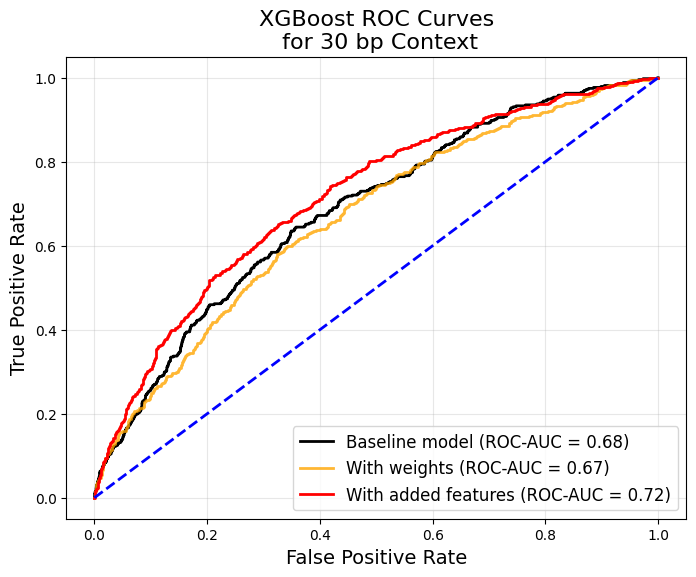

In [69]:
plt.figure(figsize=(8, 6))
models = [
    (fpr_30, tpr_30, 'Baseline model', 'black', '-', 1.0),
    (fpr_30_w, tpr_30_w, 'With weights', 'orange', '-', 0.8),
    (fpr_30_featured, tpr_30_featured, 'With added features', 'red', '-', 1.0),
]

for fpr, tpr, label, color, linestyle, alpha_val in models:
    current_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, linestyle=linestyle, alpha=alpha_val,
             label=f'{label} (ROC-AUC = {current_auc:.2f})')

plt.plot(np.linspace(0,1, 10), np.linspace(0,1, 10), '--', color='blue', lw=2)

plt.ylabel('True Positive Rate', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.title('XGBoost ROC Curves\n for 30 bp Context', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

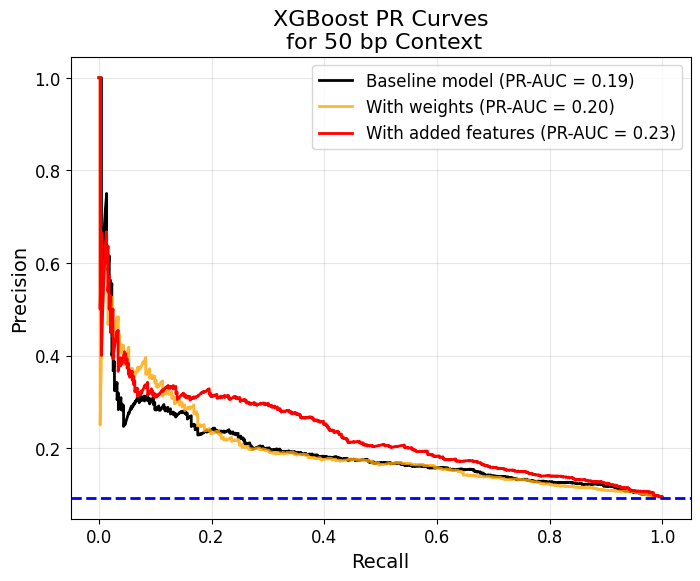

In [70]:
plt.figure(figsize=(8, 6))

pr_models = [
    (precision_50, recall_50, 'Baseline model', 'black', 1.0),
    (precision_50_w, recall_50_w, 'With weights', 'orange', 0.8),
    (precision_50_featured, recall_50_featured, 'With added features', 'red', 1.0),
]

random_level = Counter(y)[1] / (Counter(y)[0] + Counter(y)[1])

for prec, rec, label, color, alpha_val in pr_models:
    ap_score = auc(rec, prec)
    plt.plot(rec, prec, lw=2, color=color, alpha=alpha_val,
             label=f'{label} (PR-AUC = {ap_score:.2f})')

plt.axhline(y=random_level, color='blue', linestyle='--', lw=2)

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('XGBoost PR Curves\n for 50 bp Context', fontsize=16)
plt.legend(loc="upper right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

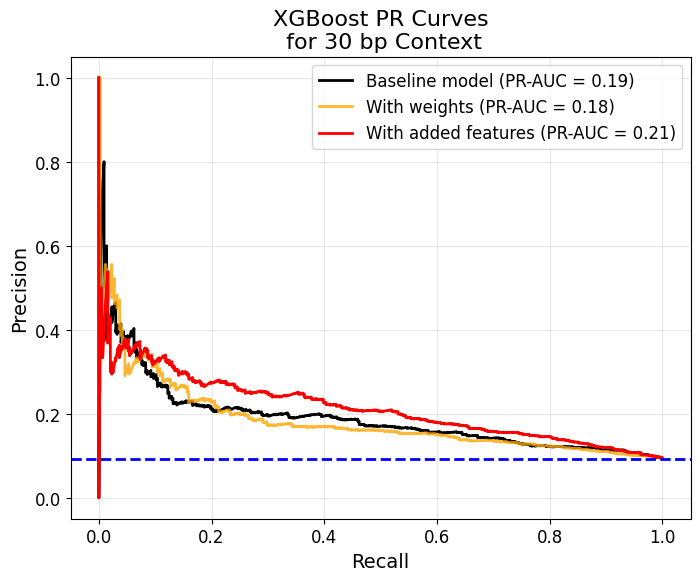

In [71]:
plt.figure(figsize=(8, 6))

pr_models = [
    (precision_30, recall_30, 'Baseline model', 'black', 1.0),
    (precision_30_w, recall_30_w, 'With weights', 'orange', 0.8),
    (precision_30_featured, recall_30_featured, 'With added features', 'red', 1.0),
]

random_level = Counter(y)[1] / (Counter(y)[0] + Counter(y)[1])

for prec, rec, label, color, alpha_val in pr_models:
    ap_score = auc(rec, prec)
    plt.plot(rec, prec, lw=2, color=color, alpha=alpha_val,
             label=f'{label} (PR-AUC = {ap_score:.2f})')

plt.axhline(y=random_level, color='blue', linestyle='--', lw=2)

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('XGBoost PR Curves\n for 30 bp Context', fontsize=16)
plt.legend(loc="upper right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()